# 单样本 JDX 推理 + Top-15 结构可视化 + Tanimoto

这个 Notebook 用于对 **一个样本**进行推理测试：
- 氢谱 `HNMR_DIR` 文件夹中 **恰好 1 个** `.jdx`
- 碳谱 `CNMR_DIR` 文件夹中 **恰好 1 个** `.jdx`
- 两个文件 **文件名(stem，经 URL decode 后)** 必须一致，且就是目标 `SMILES`

输出：
- 模型推理得到的 **Top-15 候选 SMILES 列表**
- 目标 SMILES 的化学结构式
- Top-15 每个候选的化学结构式 + 与目标的 **Tanimoto 相似度**（Morgan 指纹）

> 说明：本 Notebook **不保存任何输出文件**。

In [1]:
# ============================================================================
# 1) 配置区 - 只改这里
# ============================================================================
from pathlib import Path

# ------------ 输入：每个文件夹仅 1 个 .jdx ------------
HNMR_DIR = Path(r"D:\code\NMR_MS\test\HNMR_single")  # 这里放氢谱文件夹
CNMR_DIR = Path(r"D:\code\NMR_MS\test\CNMR_single")  # 这里放碳谱文件夹

# ------------ 模型与字典 ------------
CKPT_PATH = Path(r"D:\code\NMR_MS\model\All_OPCW_Expand_H+C\checkpoints\best_model.pt")
ALPHABET_NPY = Path(r"D:\code\NMR_MS\model\All_OPCW_Expand_H+C\alphabet.npy")

# ------------ 推理参数 ------------
TOPK_K = 15
NUM_PRED_PER_INPUT = 15      # 1 个输入生成多少条候选
DECODE_TO_SMILES = True
TRACK_GRADIENTS = True
DEVICE = 'cuda'              # 'cuda' 或 'cpu'

# ------------ 模型结构参数（需与你训练时一致） ------------
# 如果你不确定，建议从训练时保存的 config 直接复制过来
USE_HNMR = True
USE_CNMR = True
D_MODEL = 128
DIM_FEEDFORWARD = 1024
NHEAD = 4
NUM_LAYERS = 6
DROPOUT = 0.1
ACTIVATION = 'relu'
N_HNMR_FEATURES = 28000
N_CNMR_FEATURES = 80

print('✓ 配置区加载完成')
print('HNMR_DIR:', HNMR_DIR)
print('CNMR_DIR:', CNMR_DIR)
print('CKPT_PATH:', CKPT_PATH)
print('ALPHABET_NPY:', ALPHABET_NPY)

✓ 配置区加载完成
HNMR_DIR: D:\code\NMR_MS\test\HNMR_single
CNMR_DIR: D:\code\NMR_MS\test\CNMR_single
CKPT_PATH: D:\code\NMR_MS\model\All_OPCW_Expand_H+C\checkpoints\best_model.pt
ALPHABET_NPY: D:\code\NMR_MS\model\All_OPCW_Expand_H+C\alphabet.npy


In [2]:
# ============================================================================
# 2) 依赖导入（与训练/推理保持一致）
# ============================================================================
import urllib.parse
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from torch.utils.data import DataLoader
import nmrglue as ng

from nmr.data import create_dataset
from nmr.models import create_model
from nmr.inference.inference import run_inference
from nmr.scripts.top_level_utils import specific_update

# 结构绘制 / 相似度
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from rdkit.Chem.Draw import rdMolDraw2D

print('✓ 导入完成')
print('torch:', torch.__version__)

✓ 导入完成
torch: 2.5.1


In [3]:
# ============================================================================
# 3) 预处理函数（复用 build_training_data / 你现有 batch notebook 的逻辑）
# ============================================================================
HNMR_PPM_MIN = -2.0
HNMR_PPM_MAX = 12.0
HNMR_VECTOR_SIZE = 28000

CNMR_PPM_MIN = 0.0
CNMR_PPM_MAX = 230.0
CNMR_VECTOR_SIZE = 80
CNMR_THRESHOLD = 0.05

TOTAL_VECTOR_SIZE = HNMR_VECTOR_SIZE + CNMR_VECTOR_SIZE

def read_jdx_file(file_path: Path):
    dic, raw_data = ng.fileio.jcampdx.read(str(file_path))
    obs_freq = float(dic.get('.OBSERVEFREQUENCY', dic.get('OBSERVEFREQUENCY', [0]))[0])
    first_x = float(dic.get('FIRSTX', [0])[0])
    delta_x = float(dic.get('DELTAX', [0])[0])
    n_points = len(raw_data)

    freq_axis = first_x + np.arange(n_points) * delta_x  # Hz
    ppm_axis = freq_axis / obs_freq if obs_freq > 0 else freq_axis  # ppm

    intensity = np.array(raw_data, dtype=np.float64)
    min_intensity = np.min(intensity)
    if min_intensity < 0:
        intensity = intensity - min_intensity

    max_intensity = np.max(intensity)
    if max_intensity > 0:
        intensity = intensity / max_intensity
    else:
        intensity = np.zeros_like(intensity)

    return ppm_axis, intensity

def process_hnmr_spectrum(ppm_axis, intensity, target_ppm_min=HNMR_PPM_MIN, target_ppm_max=HNMR_PPM_MAX, target_size=HNMR_VECTOR_SIZE):
    target_ppm = np.linspace(target_ppm_min, target_ppm_max, target_size, dtype=np.float64)
    valid_mask = np.isfinite(ppm_axis) & np.isfinite(intensity)
    ppm_clean = ppm_axis[valid_mask]
    intensity_clean = intensity[valid_mask]
    if len(ppm_clean) <= 1:
        return target_ppm.astype(np.float32), np.zeros(target_size, dtype=np.float32)
    order = np.argsort(ppm_clean)
    ppm_sorted = ppm_clean[order]
    intensity_sorted = intensity_clean[order]
    target_intensity = np.interp(x=target_ppm, xp=ppm_sorted, fp=intensity_sorted, left=0.0, right=0.0)
    target_intensity = np.clip(target_intensity, 0.0, None).astype(np.float32)
    return target_ppm.astype(np.float32), target_intensity

def process_cnmr_spectrum(ppm_axis, intensity, ppm_min=CNMR_PPM_MIN, ppm_max=CNMR_PPM_MAX, num_bins=CNMR_VECTOR_SIZE, threshold=CNMR_THRESHOLD):
    bin_edges = np.linspace(ppm_min, ppm_max, num_bins + 1)
    binary_vector = np.zeros(num_bins, dtype=np.float32)
    valid_mask = np.isfinite(ppm_axis) & np.isfinite(intensity)
    ppm_clean = ppm_axis[valid_mask]
    intensity_clean = intensity[valid_mask]
    if len(ppm_clean) == 0:
        return binary_vector
    for i in range(num_bins):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i + 1]
        in_bin_mask = (ppm_clean >= bin_start) & (ppm_clean < bin_end)
        if np.any(in_bin_mask):
            max_intensity_in_bin = np.max(intensity_clean[in_bin_mask])
            if max_intensity_in_bin > threshold:
                binary_vector[i] = 1.0
    return binary_vector

print('✓ 预处理函数就绪')

✓ 预处理函数就绪


In [4]:
# ============================================================================
# 4) 读取单个样本（每个目录一个 jdx；文件名=目标 SMILES）
# ============================================================================
assert HNMR_DIR.exists(), f'HNMR_DIR 不存在: {HNMR_DIR}'
assert CNMR_DIR.exists(), f'CNMR_DIR 不存在: {CNMR_DIR}'
assert CKPT_PATH.exists(), f'CKPT_PATH 不存在: {CKPT_PATH}'
assert ALPHABET_NPY.exists(), f'ALPHABET_NPY 不存在: {ALPHABET_NPY}'

hnmr_files = sorted(HNMR_DIR.glob('*.jdx'))
cnmr_files = sorted(CNMR_DIR.glob('*.jdx'))
assert len(hnmr_files) == 1, f'HNMR_DIR 需要恰好 1 个 .jdx，当前: {len(hnmr_files)}'
assert len(cnmr_files) == 1, f'CNMR_DIR 需要恰好 1 个 .jdx，当前: {len(cnmr_files)}'

hnmr_file = hnmr_files[0]
cnmr_file = cnmr_files[0]
target_smiles_h = urllib.parse.unquote(hnmr_file.stem)
target_smiles_c = urllib.parse.unquote(cnmr_file.stem)
assert target_smiles_h == target_smiles_c, f'两文件名 decode 后不一致: H={target_smiles_h} C={target_smiles_c}'
target_smiles = target_smiles_h

print('target_smiles:', target_smiles)
print('hnmr_file:', hnmr_file)
print('cnmr_file:', cnmr_file)

target_smiles: COP(C)(=O)F
hnmr_file: D:\code\NMR_MS\test\HNMR_single\COP(C)(=O)F.jdx
cnmr_file: D:\code\NMR_MS\test\CNMR_single\COP(C)(=O)F.jdx


In [5]:
# ============================================================================
# 5) 单样本预处理 -> 写入内存数组（不落盘）
#    为了复用 create_dataset() 的接口，这里仍然走其数据管线：
#    - 临时写到 output_dir 会更简单，但你要求不保存输出；
#    - 因此这里采用：直接构造一个最小 Dataset 替代方案（只支持这个 notebook 使用）。
#
# 注意：仓库的 create_dataset() 入口是基于文件路径的；
#       所以这里我们改用一个轻量 DataLoader：batch 形状对齐 inference_fxns 期望。
# ============================================================================
hnmr_ppm, hnmr_intensity = read_jdx_file(hnmr_file)
_, hnmr_vec = process_hnmr_spectrum(hnmr_ppm, hnmr_intensity)
cnmr_ppm, cnmr_intensity = read_jdx_file(cnmr_file)
cnmr_vec = process_cnmr_spectrum(cnmr_ppm, cnmr_intensity)

x_vec = np.concatenate([hnmr_vec, cnmr_vec], axis=0).astype(np.float32)
assert x_vec.shape[0] == TOTAL_VECTOR_SIZE

# 推理函数一般吃 torch tensor + smiles 列表；这里尽量模仿 dataset 的 batch 结构
# batch: (x, y, smiles, *others?) —— 具体以 inference_fxns 为准
# 用最稳妥的方式：复用 create_dataset 管线（需要写临时文件）。
print('✓ 单样本谱图向量准备完成:', x_vec.shape)

✓ 单样本谱图向量准备完成: (28080,)


## 6) 关于“不保存输出”的实现方式

仓库的 `create_dataset()` 目前只接受 `*.h5` / `*.npy` 路径作为输入。为了完全复用训练期的数据管线（token/alphabet/ctrl tokens 等），这里采用 **NamedTemporaryFile** 在系统临时目录写入很小的临时文件，并在 notebook 内自动清理。

这不会在你的项目目录产生任何输出文件，同时最大程度保证与训练/推理一致。

In [6]:
# ============================================================================
# 6) 用临时文件复用 create_dataset()（自动清理，不在项目目录落盘）
# ============================================================================
import tempfile
import h5py

tmp_dir = tempfile.TemporaryDirectory(prefix='nmr_single_infer_')
tmp_path = Path(tmp_dir.name)

h5_path = tmp_path / 'single.h5'
smi_path = tmp_path / 'single_smiles.npy'
lbl_path = tmp_path / 'dummy_labels.h5'

with h5py.File(h5_path, 'w') as hf:
    hf.create_dataset('spectra', data=x_vec.reshape(1, -1), compression='gzip', compression_opts=9)

# dummy labels：按仓库默认 957
with h5py.File(lbl_path, 'w') as hf:
    hf.create_dataset('substructure_labels', data=np.zeros((1, 957), dtype=np.float32), compression='gzip')

smiles_bytes = np.array([target_smiles.encode('utf-8')], dtype=object)
np.save(smi_path, smiles_bytes)

print('✓ 临时输入已准备（位于系统临时目录，会自动清理）')
print('  ', h5_path)
print('  ', smi_path)
print('  ', lbl_path)

✓ 临时输入已准备（位于系统临时目录，会自动清理）
   C:\Users\26322\AppData\Local\Temp\nmr_single_infer_hd64rq4c\single.h5
   C:\Users\26322\AppData\Local\Temp\nmr_single_infer_hd64rq4c\single_smiles.npy
   C:\Users\26322\AppData\Local\Temp\nmr_single_infer_hd64rq4c\dummy_labels.h5


In [7]:
# ============================================================================
# 7) 构建 Dataset + Dataloader（复用训练期 create_dataset 管线）
# ============================================================================
device = torch.device(DEVICE if (DEVICE == 'cpu' or torch.cuda.is_available()) else 'cpu')
print('device:', device)

dataset_args = {
    'spectra_file': [str(h5_path)],
    'smiles_file': [str(smi_path)],
    'label_file': [str(lbl_path)],
    'input_generator': 'SpectrumRepresentationUnprocessed',
    'input_generator_addn_args': {},
    'target_generator': 'SMILESRepresentationTokenized',
    'target_generator_addn_args': {},
    'alphabet': str(ALPHABET_NPY),
    'front_load_data_processing': True,
    'eps': 0.005,
}

datasets, updated_dataset_args = create_dataset(dataset_args, torch.float32, device)
dataset = datasets[0]
print('✓ dataset size:', len(dataset))

size_dict = dataset.get_sizes()
token_dict = dataset.get_ctrl_tokens()
max_len_dict = dataset.get_max_seq_len()
total_dict = {**size_dict, **token_dict, 'max_lengths': [max_len_dict]}
print('source_size:', size_dict.get('source_size'))
print('target_size:', size_dict.get('target_size'))
print('tgt_start_token:', token_dict.get('tgt_start_token'))
print('tgt_stop_token :', token_dict.get('tgt_stop_token'))
print('tgt_pad_token  :', token_dict.get('tgt_pad_token'))

dloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
print('✓ dataloader batches:', len(dloader))

device: cuda
Preprocessing all data at once...


100%|██████████| 1/1 [00:00<00:00, 59.23it/s]

✓ dataset size: 1
source_size: 28085
target_size: 82
tgt_start_token: 80
tgt_stop_token : 81
tgt_pad_token  : 79
✓ dataloader batches: 1


In [8]:
# ============================================================================
# 8) 构建并加载模型（复用训练期 create_model）
# ============================================================================
model_args = {
    'model_type': 'TransformerModel',
    'load_model': None,
    'load_optimizer': False,
    'model_args': {
        'src_embed': 'convolutional',
        'src_embed_options': {
            'n_hnmr_features': int(N_HNMR_FEATURES),
            'n_cnmr_features': int(N_CNMR_FEATURES),
            'use_hnmr': bool(USE_HNMR),
            'use_cnmr': bool(USE_CNMR),
            'add_pos_encode': True,
            'pool_variation': 'max',
            'pool_size_1': 12,
            'out_channels_1': 64,
            'kernel_size_1': 5,
            'pool_size_2': 20,
            'out_channels_2': 128,
            'kernel_size_2': 9,
        },
        'tgt_embed': 'nn.embed',
        'tgt_embed_options': {},
        'src_forward_function': 'src_fwd_fxn_conv_embedding',
        'tgt_forward_function': 'tgt_fwd_fxn_basic',
        'source_size': None,
        'target_size': None,
        'd_model': int(D_MODEL),
        'dim_feedforward': int(DIM_FEEDFORWARD),
        'nhead': int(NHEAD),
        'num_encoder_layers': int(NUM_LAYERS),
        'num_decoder_layers': int(NUM_LAYERS),
        'dropout': float(DROPOUT),
        'activation': str(ACTIVATION),
        'src_pad_token': None,
        'tgt_pad_token': None,
    }
}

model_args = specific_update(model_args, total_dict)
model, updated_model_args = create_model(model_args, torch.float32, device)
model = model.to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print('✓ 模型加载完成')

Final sequence length after conv embedding:
116
✓ 模型加载完成
✓ 模型加载完成


In [9]:
# ============================================================================
# 9) Top-K 推理（Top-15 候选）
# ============================================================================
pred_gen_opts = {
    'num_pred_per_tgt': int(NUM_PRED_PER_INPUT),
    'sample_val': int(TOPK_K),
    'tgt_stop_token': int(token_dict['tgt_stop_token']),
    'tgt_start_token': int(token_dict['tgt_start_token']),
    'track_gradients': bool(TRACK_GRADIENTS),
    'alphabet': str(ALPHABET_NPY),
    'decode': bool(DECODE_TO_SMILES),
    'infer_fwd_fxn': 'generic',
}
inference_args = {
    'pred_gen_fn': 'infer_transformer_model',
    'pred_gen_opts': pred_gen_opts,
    'write_freq': 1,
}
predictions = run_inference(model=model, dataloader=dloader, device=device, **inference_args)
print('✓ 推理完成，records:', len(predictions))

# 预计结构：[(targets, preds, smiles, seq_scores)]
targets, pred_list, smiles_list, seq_scores = predictions[0]
pred_smiles = list(pred_list) if pred_list is not None else []
pred_smiles = [str(s) for s in pred_smiles][:15]
print('Top-15 预测 SMILES:')
for i, s in enumerate(pred_smiles, start=1):
    print(f'{i:02d}: {s}')

On batch 0
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
On iteration 0
On iteration 10
✓ 推理完成，records: 1
Top-15 预测 SMILES:
01: COP(C)(=O)Cl
02: COP(C)(=O)F
03: COP(C)(=O)F
04: C

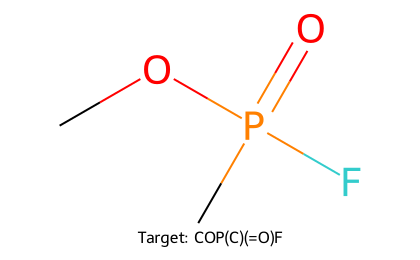

In [11]:
# ============================================================================
# 10) RDKit：绘制目标结构式
# ============================================================================
def mol_from_smiles(s: str):
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None
    return Chem.MolFromSmiles(s)

target_mol = mol_from_smiles(target_smiles)
assert target_mol is not None, f'目标 SMILES 解析失败: {target_smiles}'

# 注意：legend 不能被换行拆开，否则会触发 SyntaxError
Draw.MolToImage(target_mol, size=(420, 260), legend=f'Target: {target_smiles}')

[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator
[18:00:00] DEPRECATION WARNING: please use MorganGenerator


,rank,smiles,tanimoto
0,1,COP(C)(=O)Cl,0.500000
1,2,COP(C)(=O)F,1.000000
2,3,COP(C)(=O)F,1.000000
3,4,COP(C)(=S)SF,0.333333
4,5,COP(C)(=O)F,1.000000
5,6,COP(C)(=O)F,1.000000
6,7,COP(C)(=O)F,1.000000
7,8,COP(C)(=O)F,1.000000
8,9,CP(=O)(F)OC,1.000000
9,10,COP(C)(=O)F,1.000000


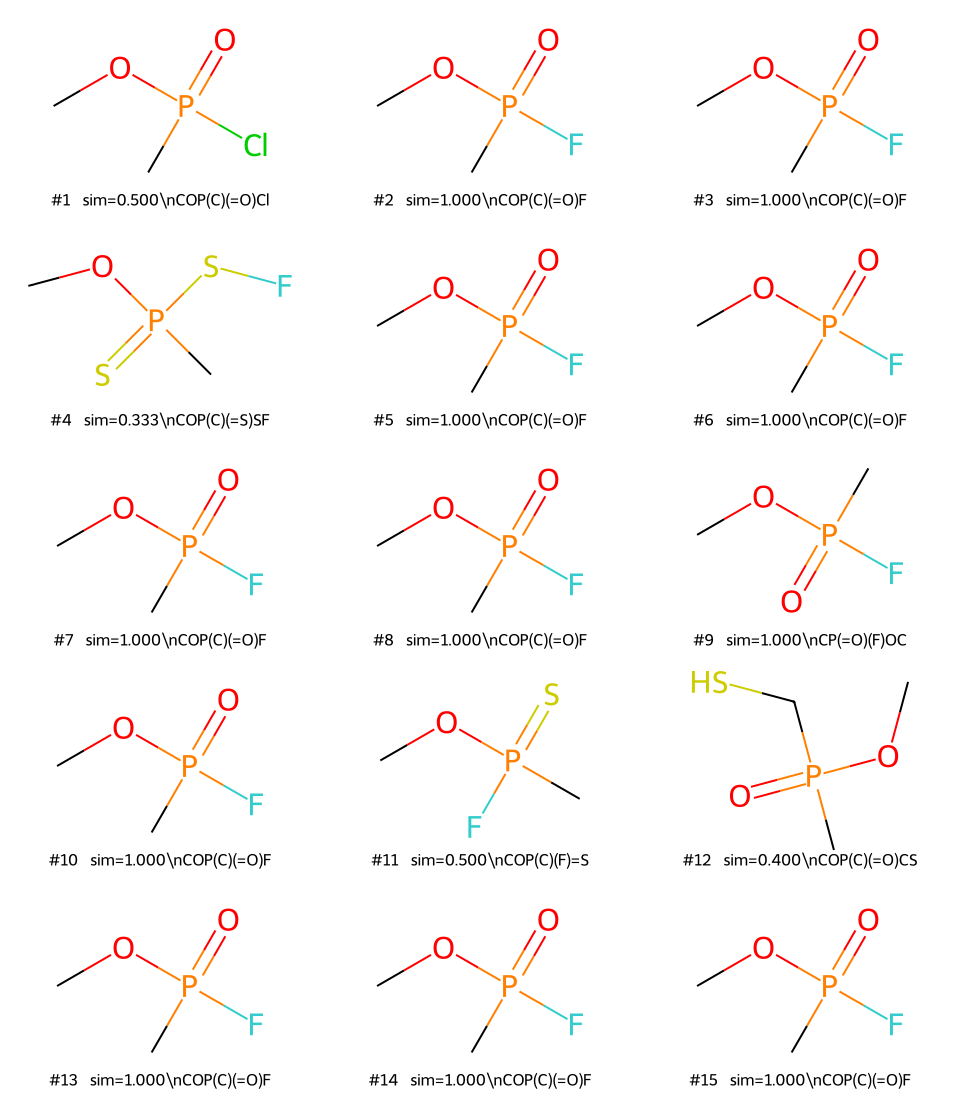

In [12]:
# ============================================================================
# 11) 计算 Top-15 的 Tanimoto，并绘制候选结构式（带相似度）
# ============================================================================
FINGERPRINT_RADIUS = 2
FINGERPRINT_NBITS = 2048

def smiles_to_fp(smiles: str, radius: int = FINGERPRINT_RADIUS, nbits: int = FINGERPRINT_NBITS):
    m = mol_from_smiles(smiles)
    if m is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nbits)

target_fp = smiles_to_fp(target_smiles)
assert target_fp is not None, '目标分子指纹计算失败'

cands = []
for rank, smi in enumerate(pred_smiles, start=1):
    m = mol_from_smiles(smi)
    if m is None:
        cands.append((rank, smi, None, np.nan))
        continue
    fp = smiles_to_fp(smi)
    sim = float(DataStructs.TanimotoSimilarity(target_fp, fp)) if fp is not None else np.nan
    cands.append((rank, smi, m, sim))

# 打印表格
import pandas as pd
df = pd.DataFrame([{'rank': r, 'smiles': s, 'tanimoto': sim} for r, s, _, sim in cands])
display(df)

# 画网格图（包含：rank + tanimoto + smiles）
mols = [m for _, _, m, _ in cands]
legends = [
    (f'#{r}  sim={sim:.3f}\\n{s}' if np.isfinite(sim) else f'#{r}  sim=NaN\\n{s}')
    for r, s, _, sim in cands
]

img = Draw.MolsToGridImage(
    mols,
    legends=legends,
    molsPerRow=3,
    subImgSize=(320, 220),
)
img

## 12) 清理临时文件

如果你想立即删除临时文件（建议执行），运行下一格。

In [ ]:
tmp_dir.cleanup()
print('✓ 已清理临时目录')